### Retiro Fugas

In [15]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text

fecha_mes_base='2026-06-01'

filename='LIBRO.xlsx'

In [16]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text

fecha_mes_base='2026-06-01'

name_dni='DNI'

ruta_archivo = os.path.join(ruta_csv, filename)
df = pd.read_excel(ruta_archivo)

df[f"{name_dni}"] = (
    df[f"{name_dni}"]
    .astype(str)
    .str.zfill(8)
)


In [17]:
df = df.rename(columns={
    f'{name_dni}': 'NumDoc'
})

In [18]:
engine_kishin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
	select NumDoc
	from DANTALION.dbo.Base_Maestra_Diners_Vigente
    WHERE RETIRO IS NULL
    and marca='PPD PLUS'
"""
df_tc = pd.read_sql(query, engine_kishin)

In [19]:
df = df.merge(df_tc, on='NumDoc', how='inner')
list_dni = (
    df['NumDoc']
    .dropna()
    .drop_duplicates()
    .tolist()
)
in_clause = ",".join(f"'{x}'" for x in list_dni)



In [20]:
in_clause

''

In [12]:
fecha_mes_base

'2026-06-01'

In [13]:
try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners
            SET RETIRO = 'RETIRO'
            WHERE NUMERO_DOCUMENTO IN ({in_clause})
                and TRY_CONVERT(DATE, fecha_envio) >= TRY_CONVERT(DATE, '{fecha_mes_base}')
                AND TRY_CONVERT(DATE, fecha_envio) < DATEADD(MONTH, 1, TRY_CONVERT(DATE, '{fecha_mes_base}'))
                AND MARCA='PPD'
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)

(pyodbc.ProgrammingError) ('42000', "[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Sintaxis incorrecta cerca de ')'. (102) (SQLExecDirectW)")
[SQL: 
            UPDATE DANTALION.dbo.Base_Maestra_Diners
            SET RETIRO = 'RETIRO'
            WHERE NUMERO_DOCUMENTO IN ()
                and TRY_CONVERT(DATE, fecha_envio) >= TRY_CONVERT(DATE, '2026-06-01')
                AND TRY_CONVERT(DATE, fecha_envio) < DATEADD(MONTH, 1, TRY_CONVERT(DATE, '2026-06-01'))
                AND MARCA='PPD'
        ]
(Background on this error at: https://sqlalche.me/e/20/f405)


In [6]:

server_sql = server_kishin
db_sql = "DANTALION"
user_sql = user_kishin
pwd_sql = pwd_kishin

engine_kishin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)


In [ ]:


ruta_archivo = os.path.join(ruta_csv, filename)
df = pd.read_excel(ruta_archivo)
df['NumDoc'] = df['Cliente'].str.extract(r'DNI-(\d+)')
df=df[df['Motivo']!='COBRANZA']
df['fecha'] = df['Fecha de creación'].dt.date
df['hora'] = df['Fecha de creación'].dt.time
df=df[[ 'Canal', 'Autor', 'Subcanal', 'Motivo', 'Importe Solicitado', 'fecha','hora','NumDoc']]


server_sql = server_kishin
db_sql = "DANTALION"
user_sql = user_kishin
pwd_sql = pwd_kishin

engine_kishin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
	select NumDoc,TIPO_PRODUCTO,RETIRO
	from DANTALION.dbo.Base_Maestra_Diners_Vigente
"""
df_ssff = pd.read_sql(query, engine_kishin)

server_sql = server_zeus
db_sql = "SAMANTHA"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
select dni as NumDoc, 1 as venta_target from SAMANTHA.dbo.Ventas_Target
where CAMPANA='Diners'
and CONVERT(DATE, FECHA) >= CONVERT(DATE, '{fecha_mes_base}')
AND CONVERT(DATE, FECHA) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
   
"""
df_venta = pd.read_sql(query, engine_zeus)

df_target = df_ssff.merge(
    df_venta,
    on='NumDoc',
    how='left'
)
df_final = df_target.merge(
    df,
    on='NumDoc',
    how='inner'
)
df_final = (
    df_final[df_final['venta_target'].isnull()]
    .drop(columns=['venta_target'])
)
df_final.rename(
    columns={
        'Importe Solicitado': 'Monto'
    },
    inplace=True
)
print(df_final.columns.tolist())

c:\Users\DATA\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


['NumDoc', 'TIPO_PRODUCTO', 'RETIRO', 'Canal', 'Autor', 'Subcanal', 'Motivo', 'Monto', 'fecha', 'hora']


In [4]:
df_final=df_final[df_final['Monto'].notnull()]

In [5]:
df_final[['TIPO_PRODUCTO','Canal', 'Monto', 'fecha']].head()


,TIPO_PRODUCTO,Canal,Monto,fecha
1,PPD,CANALES DIGITALES,35100.0,2026-06-05
3,PPD,CONTACT CENTER,15000.0,2026-06-03
4,PPD,CANALES DIGITALES,13300.0,2026-06-08
5,PPD,CONTACT CENTER,70000.0,2026-06-02
6,PPD,CANALES DIGITALES,70000.0,2026-06-01


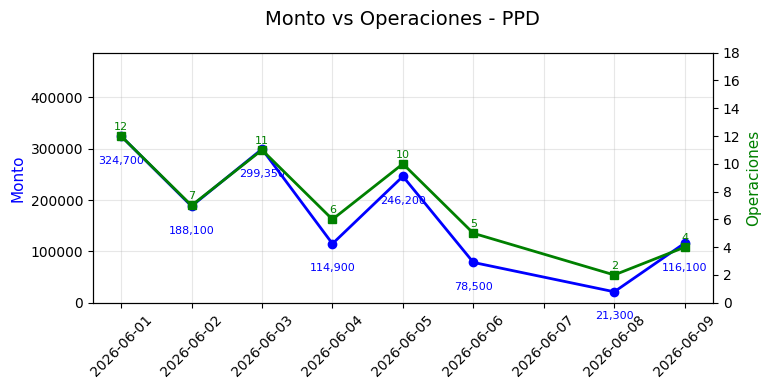

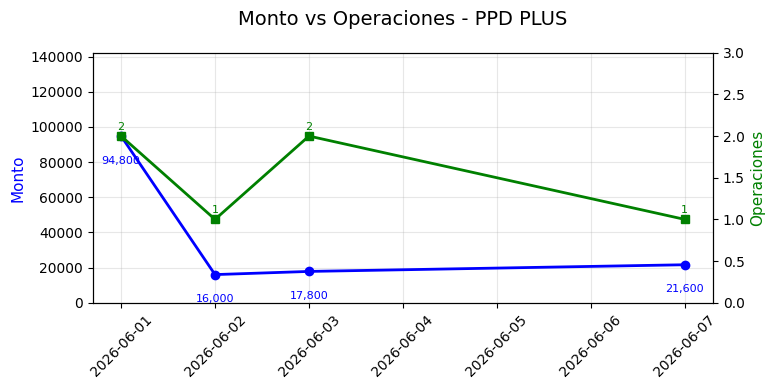

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df_final['fecha'] = pd.to_datetime(df_final['fecha'])

df_plot = (
    df_final
    .groupby(['fecha', 'TIPO_PRODUCTO'])
    .agg(
        Monto=('Monto', 'sum'),
        Operaciones=('Monto', 'count')
    )
    .reset_index()
)

for producto in df_plot['TIPO_PRODUCTO'].unique():

    df_temp = (
        df_plot[df_plot['TIPO_PRODUCTO'] == producto]
        .sort_values('fecha')
        .copy()
    )

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    ax1.plot(
        df_temp['fecha'],
        df_temp['Monto'],
        color='blue',
        marker='o',
        linewidth=2
    )

    ax2.plot(
        df_temp['fecha'],
        df_temp['Operaciones'],
        color='green',
        marker='s',
        linewidth=2
    )

    # Límites del eje izquierdo
    max_monto = df_temp['Monto'].max()
    ax1.set_ylim(0, max_monto * 1.50)

    # Límites del eje derecho
    max_operaciones = df_temp['Operaciones'].max()
    ax2.set_ylim(0, max_operaciones * 1.50)

    # Etiquetas azules: debajo, pero sin pasar el eje X
    for _, row in df_temp.iterrows():
        ax1.annotate(
            f"{int(row['Monto']):,}",
            xy=(row['fecha'], row['Monto']),
            xytext=(0, -14),
            textcoords='offset points',
            fontsize=8,
            color='blue',
            ha='center',
            va='top'
        )

    # Etiquetas verdes: encima
    for _, row in df_temp.iterrows():
        ax2.annotate(
            f"{int(row['Operaciones'])}",
            xy=(row['fecha'], row['Operaciones']),
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8,
            color='green',
            ha='center',
            va='bottom'
        )

    ax1.set_ylabel('Monto', color='blue', fontsize=11)
    ax2.set_ylabel('Operaciones', color='green', fontsize=11)

    ax1.set_title(
        f'Monto vs Operaciones - {producto}',
        fontsize=14,
        pad=20
    )

    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid(alpha=0.3)

    fig.subplots_adjust(bottom=0.30, top=0.80)

    plt.show()

In [7]:

total_monto_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD',
    'Monto'
].sum()

total_ope_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD',
    'Monto'
].count()

print(f'PPD | Monto total acumulado: {int(total_monto_ppd)} |  Total operaciones acumuladas {int(total_ope_ppd)} ')

total_monto_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD PLUS',
    'Monto'
].sum()

total_ope_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD PLUS',
    'Monto'
].count()

print(f'PPD PLUS| Monto total acumulado: {int(total_monto_ppd)} |  Total operaciones acumuladas {int(total_ope_ppd)} ')




PPD | Monto total acumulado: 1389150 |  Total operaciones acumuladas 57 
PPD PLUS| Monto total acumulado: 150200 |  Total operaciones acumuladas 6 


In [11]:
df_final['TIPO_PRODUCTO'].unique()

array(['PPD', 'PPD PLUS'], dtype=object)

In [17]:
list_dni = (
    df_final.loc[
        (df_final['RETIRO'].isna()) &
        (df_final['TIPO_PRODUCTO'].str.upper() == f'{tipo_producto}'),
        'NumDoc'
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)
list_dni

['74096428', '42791540']

In [ ]:
tipo_producto='PPD'
list_dni = (
    df_final.loc[
        (df_final['RETIRO'].isna()) &
        (df_final['TIPO_PRODUCTO'].str.upper() == f'{tipo_producto}'),
        'NumDoc'
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)

in_clause = ",".join(f"'{x}'" for x in list_dni)
try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners
            SET RETIRO = 'RETIRO'
            WHERE NumDoc IN ({in_clause})
                and CONVERT(DATE, fecha_envio) >= CONVERT(DATE, '{fecha_mes_base}')
                AND CONVERT(DATE, fecha_envio) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
                and TIPO_PRODUCTO='{tipo_producto}'
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)


Filas actualizadas: 0


In [2]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners", "SP tNumeros diners")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners", "SP actualizar diners Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners", "SP actualizar diners SA")

SP tNumeros diners | realizado | duración: 4.62 seg
SP actualizar diners Zeus | realizado | duración: 66.9 seg
SP actualizar diners SA | realizado | duración: 1.38 seg
